In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.nn.parallel import DataParallel
import numpy as np
from tqdm import tqdm

import matplotlib.pyplot as plt
from torchinfo import summary

In [3]:
import numpy as np
from tqdm import tqdm

# ── Utilities ──
def _rng(seed):
    return np.random.default_rng(seed)

def pad_to_pmax(a_time_p, p_max):
    T, p = a_time_p.shape
    out = np.zeros((T, p_max), dtype=a_time_p.dtype)
    out[:, :p] = a_time_p
    return out

def schedule_sinusoid(T, p, rng, freq_range=(1/500, 1/400), amp_range=(0.05, 0.35)):
    t = np.arange(T)
    freqs  = rng.uniform(freq_range[0], freq_range[1], size=p)
    phases = rng.uniform(0, 2*np.pi, size=p)
    amps   = rng.uniform(amp_range[0], amp_range[1], size=p)
    a = np.zeros((T, p), dtype=np.float32)
    for k in range(p):
        a[:, k] = amps[k] * np.sin(2*np.pi*freqs[k]*t + phases[k])
    return a

# ── Torus-producing TVAR generator ──
def generate_tvar_torus_data(n_samples=600, fs=100, f1=2.0, f2=3.3,
                             ar_order=3, noise_level=0.05, seed=None):
    """
    Generate TVAR data that produces a torus in embedding space.

    Strategy:
    1. Start with quasi-periodic signal (sum of 2 incommensurate frequencies)
    2. Add AR structure by making it predictable from past values
    3. Use time-varying coefficients based on the underlying oscillations
    """
    rng = np.random.default_rng(seed)
    t = np.arange(n_samples) / fs

    # Base quasi-periodic signal (creates torus topology)
    phase1 = 2 * np.pi * f1 * t
    phase2 = 2 * np.pi * f2 * t

    # Quasi-periodic components
    s1 = np.sin(phase1)
    s2 = np.sin(phase2)
    base_signal = s1 + 0.8 * s2

    # Time-varying AR coefficients (modulated by slow oscillation)
    slow_phase = 2 * np.pi * 0.5 * t

    # Generate AR with time-varying coefficients
    x = np.zeros(n_samples, dtype=np.float32)
    x[:ar_order] = base_signal[:ar_order].astype(np.float32)

    # Store true time-varying coefficients
    coeffs = np.zeros((n_samples, ar_order), dtype=np.float32)
    for i in range(n_samples):
        coeffs[i, 0] = 0.6 + 0.2 * np.sin(slow_phase[i])
        coeffs[i, 1] = -0.3 + 0.1 * np.cos(slow_phase[i])
        if ar_order >= 3:
            coeffs[i, 2] = 0.1 + 0.05 * np.sin(2 * slow_phase[i])
        for k in range(3, ar_order):
            coeffs[i, k] = 0.02 * np.sin((k + 1) * slow_phase[i])

    for i in range(ar_order, n_samples):
        ar_pred = sum(coeffs[i, j] * x[i - j - 1] for j in range(ar_order))
        forcing = 0.3 * base_signal[i]
        x[i] = ar_pred + forcing + noise_level * rng.standard_normal()

    return x.astype(np.float32), coeffs.astype(np.float32), ar_order

# ── TVAR simulator with power rejection ──
def simulate_tvar(a_time, noise_std=0.3, seed=0, burn_in=10,
                  P0=0.5, W=40, power_control=True):
    rng = _rng(seed)
    T, p = a_time.shape
    T_full = T + int(burn_in)
    x_full = np.zeros(T_full, dtype=np.float32)
    eps = rng.normal(0.0, noise_std, size=T_full).astype(np.float32)
    x_full[:p] = eps[:p]

    for t in range(p, T_full):
        tau = t - int(burn_in)
        a_t = a_time[0] if tau < 0 else a_time[tau]

        if power_control:
            window_start = max(0, t - W)
            if t - window_start > 0:
                current_power = np.mean(x_full[window_start:t]**2)
            else:
                current_power = 0.0
            if current_power > P0:
                return None, None

        lags = x_full[t-p:t][::-1]
        x_full[t] = float(np.dot(a_t, lags) + eps[t])

    x = x_full[int(burn_in):]
    return x, a_time

# ── Single-sample generator ──
def generate_tvar_sample(T=600, p_max=6, p_true=2, noise_std=0.15,
                         seed=42, max_retries=10000):
    """Generate one sinusoidal-TVAR sample for PINN showcase."""
    current_seed = seed
    for attempt in range(max_retries):
        rng = _rng(current_seed)
        a_tp = schedule_sinusoid(T=T, p=p_true, rng=rng)
        x, a_actual = simulate_tvar(a_tp, noise_std=noise_std,
                                     seed=current_seed + 123,
                                     P0=0.5, W=40, power_control=True)
        if x is not None:
            break
        current_seed += 1
    else:
        raise RuntimeError(f"Failed after {max_retries} retries")

    a_t = pad_to_pmax(a_actual.astype(np.float32), p_max)
    return x, a_t, p_true

# ── Generate dataset (N samples, sinusoidal family, balanced p) ──
# Uses torus-generating TVAR for p=3 samples, sinusoidal schedule otherwise
def generate_dataset(N=100, T=600, p_min=2, p_max=6,
                     noise_range=(0.1, 0.3), base_seed=0,
                     torus_p=3):
    p_candidates = list(range(p_min, p_max + 1))
    X = np.zeros((N, T), dtype=np.float32)
    A = np.zeros((N, T, p_max), dtype=np.float32)
    P = np.zeros(N, dtype=np.int64)
    rng = _rng(base_seed)

    for i in tqdm(range(N), desc="Generating samples"):
        p_true = p_candidates[i % len(p_candidates)]   # balanced cycling
        ns = float(rng.uniform(noise_range[0], noise_range[1]))
        s  = int(rng.integers(0, 2**31 - 1))

        if p_true == torus_p:
            # Torus-producing TVAR for this order
            f1 = 2.0 + 0.5 * rng.random()
            f2 = 3.2 + 0.8 * rng.random()
            x, coeffs, _ = generate_tvar_torus_data(
                n_samples=T, ar_order=p_true,
                f1=f1, f2=f2,
                noise_level=ns, seed=s
            )
            a_t = pad_to_pmax(coeffs, p_max)
        else:
            x, a_t, _ = generate_tvar_sample(T=T, p_max=p_max, p_true=p_true,
                                              noise_std=ns, seed=s)

        X[i] = x
        A[i] = a_t
        P[i] = p_true - p_min   # 0-indexed for cross entropy
    return X, A, P

In [4]:
def plot_tvar_sample(x, coeffs, p, W=40, P0=0.5):
    T = len(x)
    
    # Compute sliding window power
    power = np.zeros(T)
    for i in range(T):
        start = max(0, i - W + 1)
        power[i] = np.mean(x[start:i + 1] ** 2)
    
    fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
    
    # Coefficients
    for k in range(p):
        axes[0].plot(coeffs[:, k], label=f'a{k+1}')
    axes[0].set_ylabel('Coefficients')
    axes[0].legend(loc='upper right')
    
    # Signal
    axes[1].plot(x)
    axes[1].set_ylabel('Amplitude')
    
    # Power
    axes[2].plot(power, color='tab:orange')
    axes[2].axhline(P0, color='k', linestyle='--')
    axes[2].set_ylabel('Power')
    axes[2].set_xlabel('Time')
    
    plt.tight_layout()
    plt.show()

In [5]:
# Example: torus-producing TVAR(3) sample
x_torus, coeffs_torus, p_torus = generate_tvar_torus_data(
    n_samples=600, ar_order=3, f1=2.0, f2=3.3, noise_level=0.05, seed=42
)
# Pad coefficients to p_max=6 for plotting compatibility
example_sample = (x_torus, pad_to_pmax(coeffs_torus, 6), p_torus)
example_sample[0].shape, example_sample[1].shape

((600,), (600, 6))

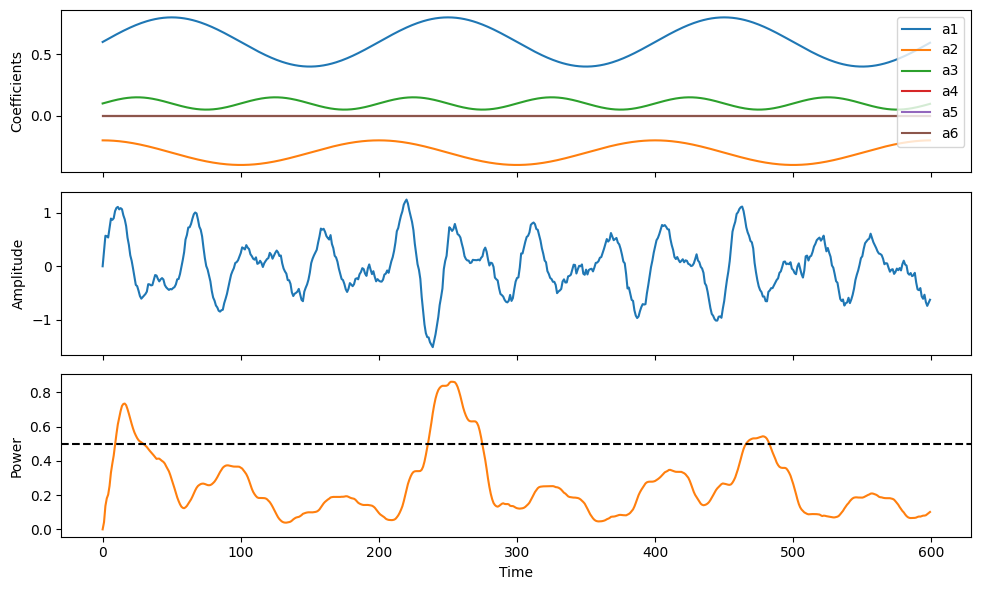

In [6]:
plot_tvar_sample(example_sample[0], example_sample[1], p=6)

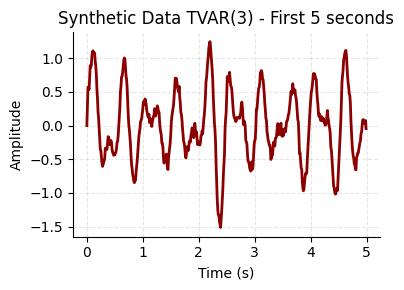

In [7]:
plot_t_snip = np.arange(len(example_sample[0])) / 100  # assuming Fs=100 Hz

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(plot_t_snip[:500], example_sample[0][:500], lw=2.0, color="darkred")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.set_title(f"Synthetic Data TVAR(3) - First 5 seconds")
ax.grid(True, ls='--', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [8]:
class TVARNet(nn.Module):
    def __init__(self, seq_len=600, n_classes=5, max_ar_order=6, hidden_dim=128):
        """
        Args:
            seq_len: Length of input sequence
            n_classes: Number of AR order classes (5 for p∈{2,3,4,5,6})
            max_ar_order: Maximum AR order for coefficient output (6 for AR(6))
            hidden_dim: Hidden layer dimension
        """
        super().__init__()
        self.seq_len = seq_len
        self.n_classes = n_classes
        self.max_ar_order = max_ar_order
        
        # P-Block: predicts order class (n_classes outputs)
        self.p_block = nn.Sequential(
            nn.Linear(seq_len, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, n_classes)
        )
        
        # D-Block: (N, seq_len + n_classes) -> (N, seq_len * max_ar_order)
        self.d_block = nn.Sequential(
            nn.Linear(seq_len + n_classes, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, seq_len * max_ar_order)
        )
    
    def forward(self, x, temperature=1.0):
        # x: (N, seq_len)
        N = x.shape[0]
        
        # P-Block: predict class (0 to n_classes-1)
        p_logits = self.p_block(x)  # (N, n_classes)
        p_soft = F.gumbel_softmax(p_logits, tau=temperature, hard=True)  # (N, n_classes)
        p_hard = torch.argmax(p_soft, dim=-1)  # (N,) values in [0, n_classes-1]
        
        # Convert class to AR order: class 0 -> p=2, class 4 -> p=6
        # So we need (p_hard + 2) coefficients active
        # Mask: indices 0...(p_hard+1) should be active
        indices = torch.arange(self.max_ar_order, device=x.device).unsqueeze(0)  # (1, max_ar_order)
        mask = (indices <= p_hard.unsqueeze(1) + 1).float()  # (N, max_ar_order)
        
        # D-Block: concat x and p_soft
        d_input = torch.cat([x, p_soft], dim=1)  # (N, seq_len + n_classes)
        coeffs_raw = self.d_block(d_input)  # (N, seq_len * max_ar_order)
        coeffs_raw = coeffs_raw.view(N, self.seq_len, self.max_ar_order)  # (N, seq_len, max_ar_order)
        
        # Apply mask
        coeffs = coeffs_raw * mask.unsqueeze(1)  # (N, seq_len, max_ar_order)
        
        # Vectorized AR: build lag matrix and do batch matmul
        # x_lagged[:, t, k] = x[:, t - k - 1]
        x_lagged = torch.zeros(N, self.seq_len, self.max_ar_order, device=x.device)
        for k in range(self.max_ar_order):
            x_lagged[:, k+1:, k] = x[:, :self.seq_len - k - 1]
        
        # x_hat[n, t] = sum_k coeffs[n, t, k] * x_lagged[n, t, k]
        x_hat = (coeffs * x_lagged).sum(dim=-1)  # (N, seq_len)
        
        return coeffs, p_logits, p_hard, x_hat


In [9]:
def loss_p(p_logits, p_true):
    return F.cross_entropy(p_logits, p_true)

def loss_ar(x, x_hat, p_max):
    return F.mse_loss(x_hat[:, p_max:], x[:, p_max:])

def loss_energy(x_hat, P0=0.5, W=40):
    # Use unfold for sliding window
    N, T = x_hat.shape
    # Pad at start so we get T windows
    x_padded = F.pad(x_hat, (W - 1, 0), mode='constant', value=0)
    windows = x_padded.unfold(1, W, 1)  # (N, T, W)
    powers = (windows ** 2).mean(dim=-1)  # (N, T)
    return ((powers - P0) ** 2).mean()

def loss_smooth(coeffs):
    diff = coeffs[:, 1:, :] - coeffs[:, :-1, :]
    return torch.mean(torch.sum(diff ** 2, dim=2))

# def loss_smooth(coeffs):
#     """
#     Penalize second derivative (curvature) of coefficients over time.
#     This prevents high-frequency oscillations.
#     """
#     # Second derivative: d²a/dt² ≈ a(t+1) - 2*a(t) + a(t-1)
#     second_deriv = coeffs[:, 2:, :] - 2 * coeffs[:, 1:-1, :] + coeffs[:, :-2, :]
#     return torch.mean(second_deriv ** 2)

def loss_order(p_logits):
    """Regularizer to prefer lower AR orders.
    Computes expected order index from softmax probabilities and penalizes higher values.
    """
    # p_logits: (N, n_classes) where class 0 -> p=2, class 4 -> p=6
    n_classes = p_logits.shape[1]
    probs = F.softmax(p_logits, dim=-1)  # (N, n_classes)
    indices = torch.arange(n_classes, device=p_logits.device, dtype=p_logits.dtype)  # [0, 1, 2, 3, 4]
    expected_order = (probs * indices).sum(dim=-1)  # (N,) expected class index
    return expected_order.mean()  # Minimize expected order

In [10]:
# Generate data
X_train, coef_train, p_train = generate_dataset(10000, p_min=2, p_max=6)
X_val, coef_val, p_val = generate_dataset(1000, p_min=2, p_max=6)

# np.savez_compressed('model/tvar_dataset.npz',
#                     X_train=X_train, coef_train=coef_train, p_train=p_train,
#                     X_val=X_val, coef_val=coef_val, p_val=p_val)

# d = np.load('model/tvar_dataset.npz')
# X_train, coef_train, \
#     p_train, X_val, coef_val, p_val = [d[k][:] for k in ['X_train', 'coef_train', 
#                                                       'p_train', 'X_val', 'coef_val', 'p_val']]
# d.close()


Generating samples: 100%|██████████| 1000/1000 [00:01<00:00, 567.63it/s]


In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    torch.cuda.init()
print(f"Using device: {device}")

# To tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
p_train = torch.tensor(p_train, dtype=torch.long)
X_val = torch.tensor(X_val, dtype=torch.float32)
p_val = torch.tensor(p_val, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train, p_train), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, p_val), batch_size=32)

# Model: n_classes=5 for p∈{2,3,4,5,6}, max_ar_order=6 for coefficient dimensions
model = TVARNet(seq_len=600, n_classes=5, max_ar_order=6, hidden_dim=128)
# model = DataParallel(model)
model = model.to(device)

Using device: cpu


In [12]:
summary(model, input_size=(32, 600), device=device)

Layer (type:depth-idx)                   Output Shape              Param #
TVARNet                                  [32, 600, 6]              --
├─Sequential: 1-1                        [32, 5]                   --
│    └─Linear: 2-1                       [32, 128]                 76,928
│    └─ReLU: 2-2                         [32, 128]                 --
│    └─Linear: 2-3                       [32, 128]                 16,512
│    └─ReLU: 2-4                         [32, 128]                 --
│    └─Linear: 2-5                       [32, 5]                   645
├─Sequential: 1-2                        [32, 3600]                --
│    └─Linear: 2-6                       [32, 128]                 77,568
│    └─ReLU: 2-7                         [32, 128]                 --
│    └─Linear: 2-8                       [32, 128]                 16,512
│    └─ReLU: 2-9                         [32, 128]                 --
│    └─Linear: 2-10                      [32, 3600]                4

In [13]:
def train(
    model,
    train_loader,
    val_loader,
    n_epochs=100,
    lr=1e-3,
    lambda_p=10.0,
    lambda_ar=1.0,
    lambda_energy=0.1,
    lambda_smooth=0.05,
    lambda_order=0.0,
    P0=0.5,
    W=40,
    p_max=6,
    device='cuda'
):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
    
    history = {
        'train_loss': [], 'train_p': [], 'train_ar': [], 'train_energy': [], 'train_smooth': [], 'train_order': [], 'train_p_acc': [],
        'val_loss': [], 'val_p': [], 'val_ar': [], 'val_energy': [], 'val_smooth': [], 'val_order': [], 'val_p_acc': []
    }
    
    pbar = tqdm(total=n_epochs, desc='Training')
    for epoch in range(n_epochs):
        # Train
        model.train()
        train_losses = {'total': [], 'p': [], 'ar': [], 'energy': [], 'smooth': [], 'order': []}
        train_correct = 0
        train_total = 0
        
        for x_batch, p_batch in train_loader:
            x_batch = x_batch.to(device)
            p_batch = p_batch.to(device)
            
            optimizer.zero_grad()
            
            coeffs, p_logits, p_hard, x_hat = model(x_batch)
            
            l_p = loss_p(p_logits, p_batch)
            l_ar = loss_ar(x_batch, x_hat, p_max)
            l_energy = loss_energy(x_hat, P0, W)
            l_smooth = loss_smooth(coeffs)
            l_order = loss_order(p_logits)
            
            total_loss = lambda_p * l_p + lambda_ar * l_ar + lambda_energy * l_energy + lambda_smooth * l_smooth + lambda_order * l_order
            
            total_loss.backward()
            optimizer.step()
            
            train_losses['total'].append(total_loss.item())
            train_losses['p'].append(l_p.item())
            train_losses['ar'].append(l_ar.item())
            train_losses['energy'].append(l_energy.item())
            train_losses['smooth'].append(l_smooth.item())
            train_losses['order'].append(l_order.item())
            
            train_correct += (p_hard == p_batch).sum().item()
            train_total += p_batch.shape[0]
        
        # Validate
        model.eval()
        val_losses = {'total': [], 'p': [], 'ar': [], 'energy': [], 'smooth': [], 'order': []}
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for x_batch, p_batch in val_loader:
                x_batch = x_batch.to(device)
                p_batch = p_batch.to(device)
                
                coeffs, p_logits, p_hard, x_hat = model(x_batch)
                
                l_p = loss_p(p_logits, p_batch)
                l_ar = loss_ar(x_batch, x_hat, p_max)
                l_energy = loss_energy(x_hat, P0, W)
                l_smooth = loss_smooth(coeffs)
                l_order = loss_order(p_logits)
                
                total_loss = lambda_p * l_p + lambda_ar * l_ar + lambda_energy * l_energy + lambda_smooth * l_smooth + lambda_order * l_order
                
                val_losses['total'].append(total_loss.item())
                val_losses['p'].append(l_p.item())
                val_losses['ar'].append(l_ar.item())
                val_losses['energy'].append(l_energy.item())
                val_losses['smooth'].append(l_smooth.item())
                val_losses['order'].append(l_order.item())
                
                val_correct += (p_hard == p_batch).sum().item()
                val_total += p_batch.shape[0]
        
        history['train_loss'].append(np.mean(train_losses['total']))
        history['train_p'].append(np.mean(train_losses['p']))
        history['train_ar'].append(np.mean(train_losses['ar']))
        history['train_energy'].append(np.mean(train_losses['energy']))
        history['train_smooth'].append(np.mean(train_losses['smooth']))
        history['train_order'].append(np.mean(train_losses['order']))
        history['train_p_acc'].append(train_correct / train_total)
        
        history['val_loss'].append(np.mean(val_losses['total']))
        history['val_p'].append(np.mean(val_losses['p']))
        history['val_ar'].append(np.mean(val_losses['ar']))
        history['val_energy'].append(np.mean(val_losses['energy']))
        history['val_smooth'].append(np.mean(val_losses['smooth']))
        history['val_order'].append(np.mean(val_losses['order']))
        history['val_p_acc'].append(val_correct / val_total)
        
        scheduler.step(history['val_loss'][-1])
        
        
        pbar.update(1)
        pbar.set_postfix(
            train=f"{history['train_loss'][-1]:.4f}",
            val=f"{history['val_loss'][-1]:.4f}",
            p_acc=f"{history['val_p_acc'][-1]:.3f}"
        )
    
    pbar.close()
    return history

In [14]:
# hyperparameters
n_epochs = 100
lr = 1e-3
lambda_p = 10
lambda_ar = 10
lambda_energy = 0.1
lambda_smooth = 150
lambda_order = 1  # Regularizer to prefer lower AR orders (higher = stronger preference for low p)
max_ar_order = 6  # max AR order for skipping initial samples in loss
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Train
history = train(
    model, train_loader, val_loader,
    n_epochs=n_epochs, lr=lr,
    lambda_p=lambda_p, lambda_ar=lambda_ar, lambda_energy=lambda_energy, 
    lambda_smooth=lambda_smooth, lambda_order=lambda_order,
    p_max=max_ar_order, device=device
)

Training: 100%|██████████| 100/100 [04:03<00:00,  2.44s/it, p_acc=0.999, train=2.5204, val=2.5325]


In [15]:
# torch.save({
#     'model_state_dict': model.state_dict(),
#     'history': history
# }, 'model/tvar_model.pt')

# Load
# checkpoint = torch.load('model/tvar_model.pt', weights_only=False)
# model.load_state_dict(checkpoint['model_state_dict'])
# history = checkpoint['history']

In [16]:
def plot_confusion_matrix(model, val_loader, device, p_min=2, p_max=6, ax=None):
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
    
    model.eval()
    all_p_pred = []
    all_p_true = []
    
    with torch.no_grad():
        for x_batch, p_batch in val_loader:
            x_batch = x_batch.to(device)
            _, _, p_hard, _ = model(x_batch)
            all_p_pred.extend(p_hard.cpu().numpy())
            all_p_true.extend(p_batch.numpy())
    
    n_classes = p_max - p_min + 1  # 5 classes for p=2,3,4,5,6
    cm = confusion_matrix(all_p_true, all_p_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=[f'p={i+p_min}' for i in range(n_classes)])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    if ax:
        ax.set_title('P Confusion Matrix')
    return cm

def plot_history(history, model=None, val_loader=None, device=None, p_min=2, p_max=6):
    fig, axes = plt.subplots(2, 6, figsize=(20, 8))
    
    metrics = ['loss', 'p', 'ar', 'energy', 'smooth', 'p_acc']
    titles = ['Total Loss', 'P Loss (CE)', 'AR Loss', 'Energy Loss', 'Smooth Loss', 'P Accuracy']
    
    # Train metrics (row 0)     
    for i, (metric, title) in enumerate(zip(metrics, titles)):
        axes[0, i].plot(history[f'train_{metric}'])
        axes[0, i].set_title(f'Train {title}')
        axes[0, i].set_xlabel('Epoch')
    
    # Val metrics (row 1, first 5)
    for i, (metric, title) in enumerate(zip(metrics[:5], titles[:5])):
        axes[1, i].plot(history[f'val_{metric}'])
        axes[1, i].set_title(f'Val {title}')
        axes[1, i].set_xlabel('Epoch')
    
    # Confusion matrix (row 1, last col)
    if model is not None and val_loader is not None and device is not None:
        plot_confusion_matrix(model, val_loader, device, p_min=p_min, p_max=p_max, ax=axes[1, 5])
    else:
        axes[1, 5].plot(history['val_p_acc'])
        axes[1, 5].set_title('Val P Accuracy')
        axes[1, 5].set_xlabel('Epoch')
    
    plt.tight_layout()
    plt.show()

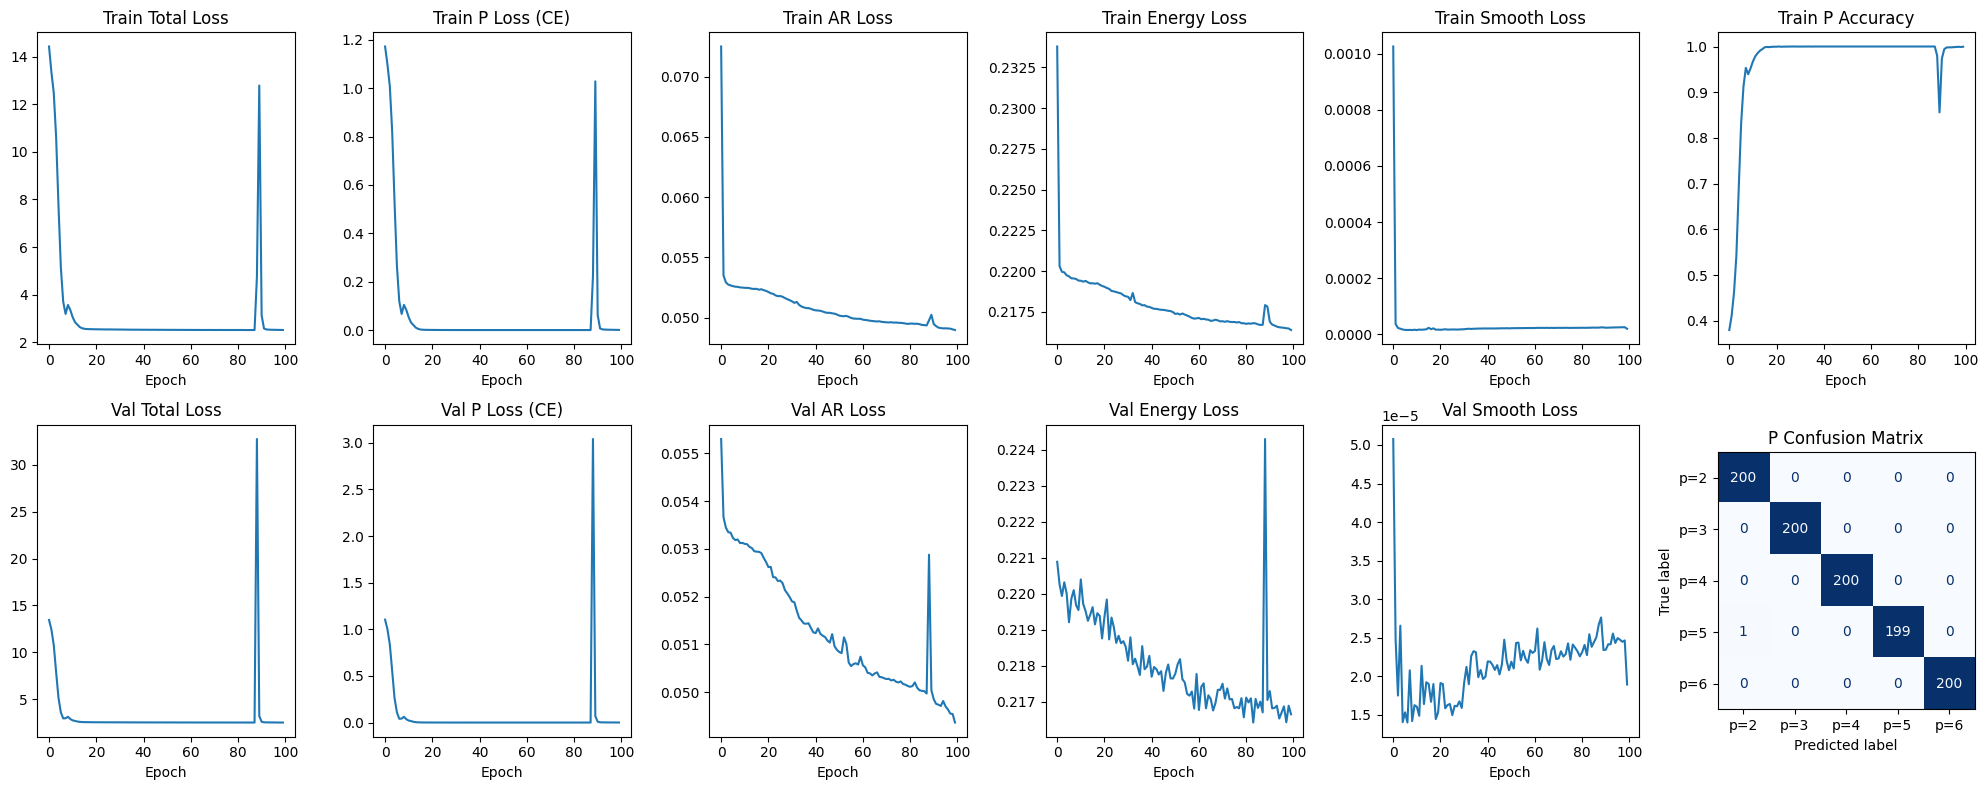

In [17]:
plot_history(history, model=model, val_loader=val_loader, device=device)

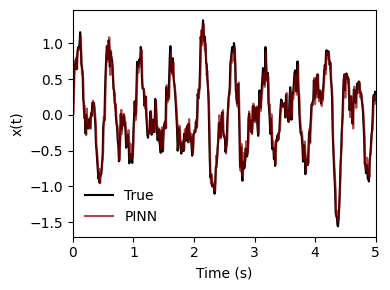

In [18]:
# Pick a sample (e.g. p=3, class index 1)
p3_mask = (p_val == 1).numpy() if torch.is_tensor(p_val) else (p_val == 1)
sample_idx = np.where(p3_mask)[0][0]

# Get true signal
x_true = X_val[sample_idx].cpu().numpy()

# Get PINN reconstruction
model.eval()
with torch.no_grad():
    x_input = X_val[sample_idx:sample_idx+1].to(device)
    _, _, _, x_hat = model(x_input)
    x_hat_np = x_hat.cpu().numpy()[0]

# Plot
T = len(x_true)
t = np.arange(T) / 100  # assuming Fs=100

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(t[:500], x_true[:500], lw=1.5, color="black", label="True")
ax.plot(t[:500], x_hat_np[:500], lw=1.5, color="darkred", alpha=0.7, label="PINN")
ax.set_xlabel("Time (s)")
ax.set_ylabel("x(t)")
ax.legend(frameon=False)

for spine in ax.spines.values():
    spine.set_visible(True)

sec_ticks = np.arange(0, 6, 1)
ax.set_xticks(sec_ticks)
ax.set_xlim([0, 5])
plt.tight_layout()
plt.show()

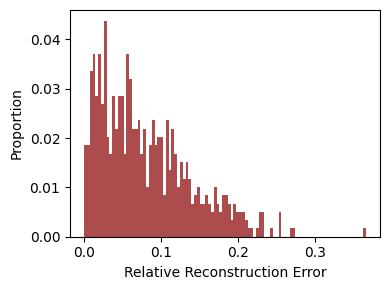

In [19]:
# Get single sample prediction
model.eval()
with torch.no_grad():
    x_input = X_val[sample_idx:sample_idx+1].to(device)
    _, _, _, x_hat = model(x_input)
    x_hat_np = x_hat.cpu().numpy()[0]

x_true = X_val[sample_idx].cpu().numpy()

# Relative error for signal
signal_errors = np.abs(x_hat_np[6:] - x_true[6:]) / np.max(np.abs(x_true[6:]) + 1e-8)

# Plot
fig, ax = plt.subplots(figsize=(4, 3))
ax.hist(signal_errors, bins=100, color="darkred", alpha=0.7, edgecolor="none",
        weights=np.ones_like(signal_errors) / len(signal_errors))
ax.set_xlabel("Relative Reconstruction Error")
ax.set_ylabel("Proportion")

for spine in ax.spines.values():
    spine.set_visible(True)

plt.tight_layout()
plt.show()

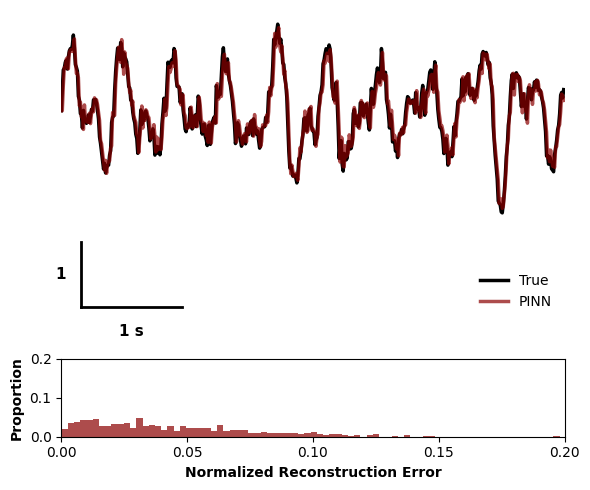

In [74]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 5), gridspec_kw={'height_ratios': [4, 1]})

# Top: signal overlay
ax1.plot(t[:500], x_true[:500], lw=2.5, color="black", label="True")
ax1.plot(t[:500], x_hat_np[:500], lw=2.5, color="darkred", alpha=0.7, label="PINN")
ax1.legend(frameon=False)
ax1.set_xlim([0, 5])

# Remove all spines and ticks for clean look
for spine in ax1.spines.values():
    spine.set_visible(False)
ax1.set_xticks([])
ax1.set_yticks([])

# Add scale bars instead of axes
# X scale bar: 1 second, placed at bottom-left
x_bar_start, x_bar_end = 0.2, 1.2  # 1 second
y_bar_bot, y_bar_top = -3, -2       # 1 unit

ax1.plot([x_bar_start, x_bar_end], [y_bar_bot, y_bar_bot], color="black", lw=2, clip_on=False)
ax1.text((x_bar_start + x_bar_end) / 2, y_bar_bot - 0.25, "1 s", ha="center", va="top", fontsize=11, fontweight="bold")

# Y scale bar: 1 unit, from -3 to -2
ax1.plot([x_bar_start, x_bar_start], [y_bar_bot, y_bar_top], color="black", lw=2, clip_on=False)
ax1.text(x_bar_start - 0.15, (y_bar_bot + y_bar_top) / 2, "1", ha="right", va="center", fontsize=11, fontweight="bold")

# Bottom: error histogram
# x_true_z = (x_true[6:] - np.mean(x_true[6:])) / np.std(x_true[6:])
# x_hat_z = (x_hat_np[6:] - np.mean(x_true[6:])) / np.std(x_true[6:])
# signal_range = np.max(x_true_z[6:])  - np.min(x_true_z[6:])
# signal_errors = np.abs(x_hat_z[6:] - x_true_z[6:]) / signal_range

signal_range = np.max(x_true[6:])  - np.min(x_true[6:])
signal_errors = np.abs(x_hat_np[6:] - x_true[6:]) / signal_range
# signal_errors = np.sqrt(np.mean((x_hat_np[6:] - x_true[6:]) ** 2))

ax2.hist(signal_errors, bins=80, color="darkred", alpha=0.7, edgecolor="none",
         weights=np.ones_like(signal_errors) / len(signal_errors))
ax2.set_xlabel("Normalized Reconstruction Error", fontweight="bold")
ax2.set_ylabel("Proportion", fontweight="bold")
ax2.set_xlim([0, 0.2])
ax2.set_xticks([0, 0.05, 0.1, 0.15, 0.2])
ax2.set_ylim([0, 0.2])


for spine in ax2.spines.values():
    spine.set_visible(True)

plt.tight_layout()
plt.show()

In [21]:
def plot_coefficients_by_p(model, X, coeffs_true, p_true, device, p_max=6, p_min=2, title=""):
    model.eval()
    
    n_classes = p_max - p_min + 1  # 5 classes for p=2,3,4,5,6
    fig, axes = plt.subplots(1, n_classes, figsize=(4 * n_classes, 4))
    
    with torch.no_grad():
        for p_idx in range(n_classes):
            ax = axes[p_idx]
            p_actual = p_idx + p_min  # True AR order: 2,3,4,5,6
            
            mask = (p_true == p_idx).numpy() if torch.is_tensor(p_true) else (p_true == p_idx)
            if not mask.any():
                ax.set_title(f'p={p_actual} (no example)')
                continue
            
            idx = np.where(mask)[0][0]
            
            if torch.is_tensor(X):
                x = X[idx:idx+1].clone().detach().to(device)
            else:
                x = torch.from_numpy(X[idx:idx+1]).float().to(device)
            
            coeffs_pred, _, p_hard, _ = model(x)
            coeffs_pred = coeffs_pred.cpu().numpy()[0]  # (600, max_ar_order)
            p_pred = p_hard.item() + p_min  # Predicted AR order
            
            # Plot true coefficients (p_actual of them)
            for k in range(p_actual):
                label = 'True' if k == 0 else None
                ax.plot(coeffs_true[idx, :, k], 'k-', alpha=0.7, label=label)
            
            # Plot predicted coefficients (p_pred of them)
            for k in range(p_pred):
                label = 'Pred' if k == 0 else None
                ax.plot(coeffs_pred[:, k], color='darkred', alpha=0.7, label=label)
            
            ax.set_title(f'True p={p_actual}, Pred p={p_pred}')
            ax.set_xlabel('Time')
            ax.set_ylabel('Coefficient')
            ax.legend()
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

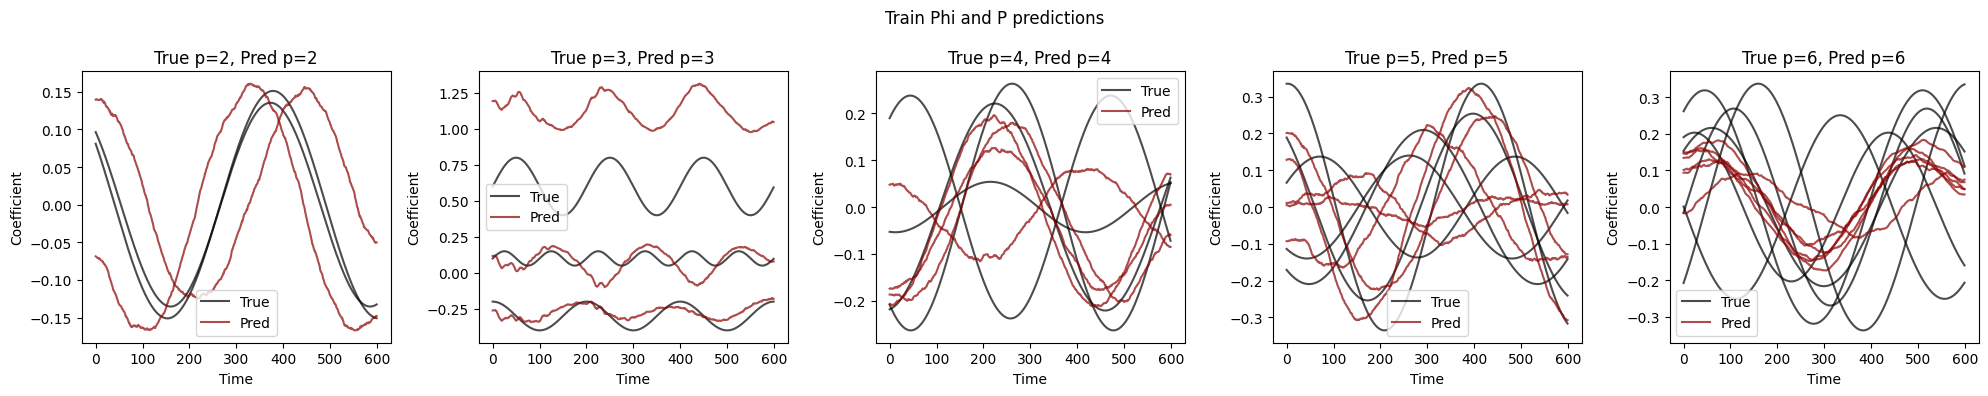

In [22]:
plot_coefficients_by_p(model, X_train, coef_train, p_train, device, title="Train Phi and P predictions")

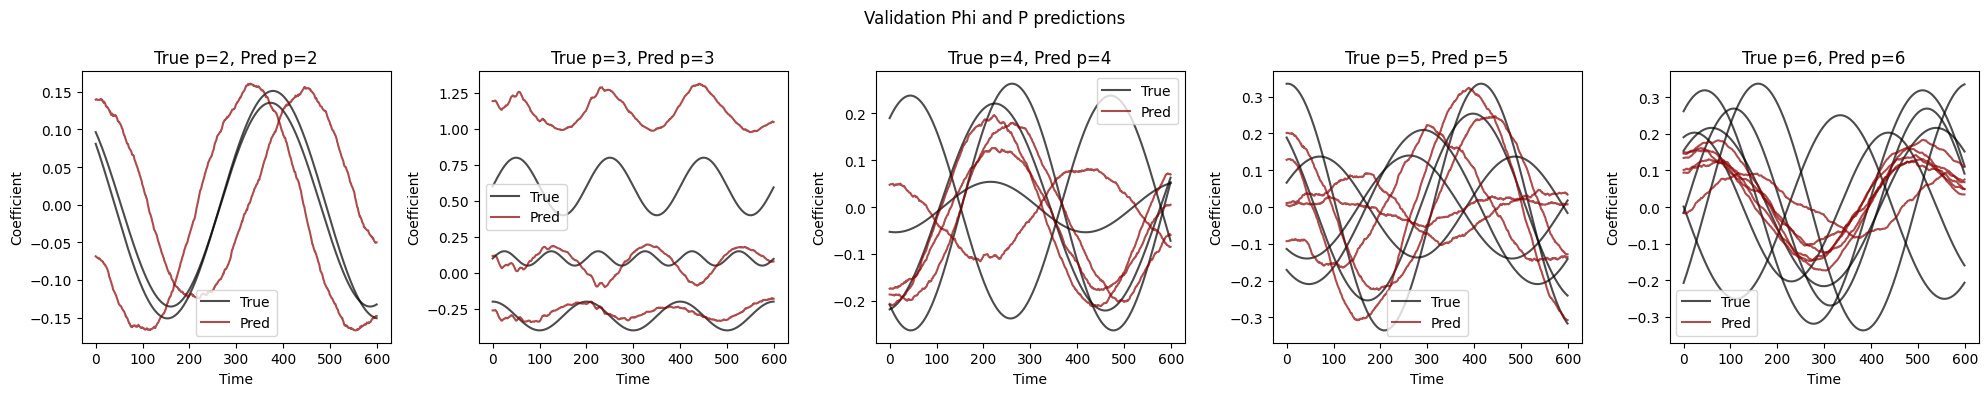

In [23]:

plot_coefficients_by_p(model, X_val, coef_val, p_val, device, title="Validation Phi and P predictions")

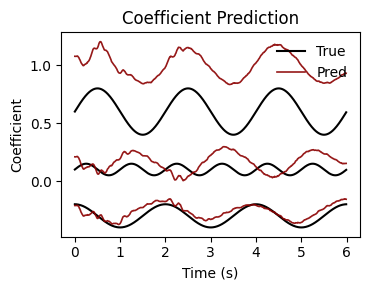

In [24]:
# Find a p=3 sample from validation set (class index 1 since p_min=2)
p3_mask = (p_val == 1).numpy() if torch.is_tensor(p_val) else (p_val == 1)
p3_idx = np.where(p3_mask)[0][15]
p_actual = 3  # AR order

# Get the signal and true coefficients
signal_p3 = X_val[p3_idx].numpy() if torch.is_tensor(X_val) else X_val[p3_idx]
coeffs_true_p3 = coef_val[p3_idx]  # (T, p_max)

# Get model predictions
model.eval()
with torch.no_grad():
    x_input = X_val[p3_idx:p3_idx+1].to(device)
    coeffs_pred, _, p_hard, _ = model(x_input)
    coeffs_pred_p3 = coeffs_pred.cpu().numpy()[0]  # (T, max_ar_order)
    p_pred = p_hard.item() + 2  # predicted AR order

# Plot coefficients like the reference image
fig, ax = plt.subplots(figsize=(4, 3))
T = len(signal_p3)
t = np.arange(T) / 100  # Time in seconds

# Plot true coefficients as time-varying lines
for k in range(p_actual):
    label = 'True' if k == 0 else None
    ax.plot(t, coeffs_true_p3[:, k], color='black', lw=1.5, label=label)

# Plot predicted coefficients as time-varying lines
for k in range(p_pred):
    label = 'Pred' if k == 0 else None
    ax.plot(t, coeffs_pred_p3[:, k], color='darkred', lw=1.2, alpha=0.9, label=label)

ax.set_title(f"Coefficient Prediction")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Coefficient")
ax.legend(frameon=False, loc="upper right")
plt.tight_layout()
plt.show()

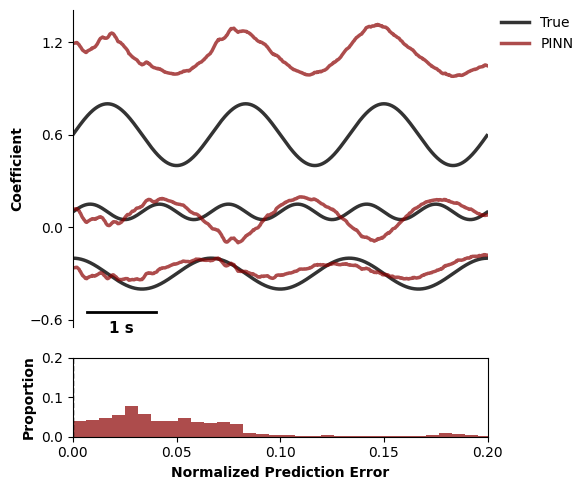

In [73]:
# Pick a sample
p3_mask = (p_val == 1).numpy() if torch.is_tensor(p_val) else (p_val == 1)
sample_idx = np.where(p3_mask)[0][0]

# Get true coefficients
coeffs_true_sample = coef_val[sample_idx]  # (T, p_max)

# Get predicted coefficients
model.eval()
with torch.no_grad():
    x_input = X_val[sample_idx:sample_idx+1].to(device)
    coeffs_pred, _, p_hard, _ = model(x_input)
    coeffs_pred_sample = coeffs_pred.cpu().numpy()[0]  # (T, max_ar_order)
    p_pred = p_hard.item() + 2

p_actual = 3
T = coeffs_true_sample.shape[0]
t = np.arange(T) / 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 5), height_ratios=[4, 1])

# Top: coefficient overlay
for k in range(p_actual):
    label_true = "True" if k == 0 else None
    label_pred = "PINN" if k == 0 else None
    ax1.plot(t, coeffs_true_sample[:, k], color="black", lw=2.5, alpha=0.8, label=label_true)
    ax1.plot(t, coeffs_pred_sample[:, k], color="darkred", lw=2.5, alpha=0.7, label=label_pred)

ax1.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
ax1.set_xlim([0, T / 100])
ax1.set_ylabel("Coefficient", fontweight="bold")
ax1.yaxis.set_major_locator(plt.MaxNLocator(4))

# Remove top, right, bottom spines; keep left for y-axis
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.set_xticks([])

# Add scale bar for x-axis only (1 second)
y_min = min(coeffs_true_sample[:, :p_actual].min(), coeffs_pred_sample[:, :p_actual].min())
x_bar_start, x_bar_end = 0.2, 1.2  # 1 second
y_bar_bot = y_min - 0.15

ax1.plot([x_bar_start, x_bar_end], [y_bar_bot, y_bar_bot], color="black", lw=2, clip_on=False)
ax1.text((x_bar_start + x_bar_end) / 2, y_bar_bot - 0.06, "1 s", ha="center", va="top", fontsize=11, fontweight="bold")

# Bottom: absolute coefficient error histogram

coeff_range = np.max(coeffs_true_sample[:, :p_actual]) - np.min(coeffs_true_sample[:, :p_actual])
errors = (np.abs(coeffs_pred_sample[:, :p_actual] - coeffs_true_sample[:, :p_actual]) / coeff_range).flatten()
# errors = (np.abs(coeffs_pred_sample[:, :p_actual] - coeffs_true_sample[:, :p_actual])).flatten()


ax2.hist(errors, bins=80, color="darkred", alpha=0.7, edgecolor="none",
         weights=np.ones_like(errors) / len(errors))
ax2.axvline(0, color="black", lw=1, linestyle="--")
ax2.set_xlabel("Normalized Prediction Error", fontweight="bold")
ax2.set_ylabel("Proportion", fontweight="bold")
ax2.set_xlim([0, 0.2])
ax2.xaxis.set_major_locator(plt.MaxNLocator(4))
ax2.set_ylim([0, 0.2])

for spine in ax2.spines.values():
    spine.set_visible(True)

plt.tight_layout()
plt.show()

In [26]:
import sys
sys.path.insert(0, '/home/rudra/Documents/NeuralFieldManifold')

In [27]:
from NeuralFieldManifold.models import AR
from NeuralFieldManifold.embedders import embed


In [28]:
p3_indices = np.where(p_val.numpy() == 1)[0]
print(f"Found {len(p3_indices)} torus-TVAR(3) samples in validation set")

sample_idx = p3_indices[0]

xs = X_val.cpu().numpy()[sample_idx]

# Use PINN prediction instead of OLS
model.eval()
with torch.no_grad():
    x_input = X_val[sample_idx:sample_idx+1].to(device)
    coeffs_pred, _, p_hard, x_hat = model(x_input)
    p_pred = p_hard.item() + 2  # predicted AR order
    x_hat_np = x_hat.cpu().numpy()[0]  # (600,) full PINN prediction

# Use full signal for embedding (skip first p_max samples where x_hat is zero)
p_max = 6
true_full = xs[p_max:]
pinn_pred_full = x_hat_np[p_max:]

# Metrics
mse = np.mean((true_full - pinn_pred_full) ** 2)
mae = np.mean(np.abs(true_full - pinn_pred_full))
corr = np.corrcoef(true_full, pinn_pred_full)[0, 1]

print(f"PINN (pred p={p_pred}): MSE={mse:.6f}, MAE={mae:.6f}, corr={corr:.3f}")

Found 200 torus-TVAR(3) samples in validation set
PINN (pred p=3): MSE=0.024182, MAE=0.125066, corr=0.953


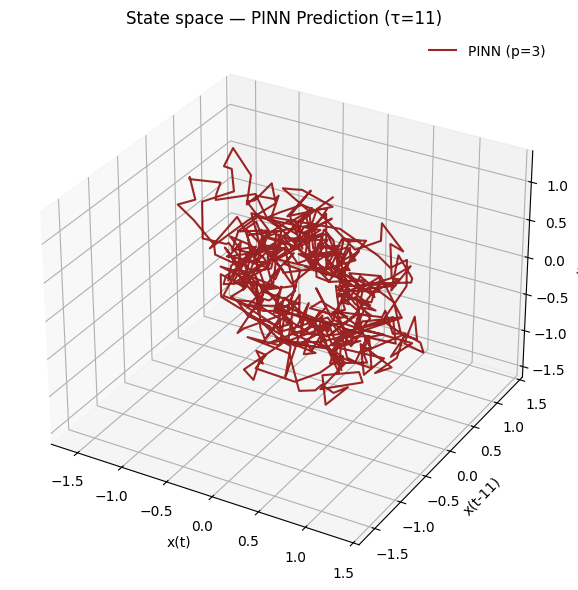

In [29]:
def plot_state_space(X3_true, X3_pred, p, tau, method_label="PINN", color_true="black", color_pred="darkred"):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    # ax.plot(X3_true[:,0], X3_true[:,1], X3_true[:,2], label="TRUE", color=color_true, alpha=0.85)
    ax.plot(X3_pred[:,0], X3_pred[:,1], X3_pred[:,2], label=f"{method_label} (p={p})", color=color_pred, alpha=0.85)
    ax.set_title(f"State space — PINN Prediction (τ={tau})")
    ax.set_xlabel("x(t)")
    ax.set_ylabel(f"x(t-{tau})")
    ax.set_zlabel(f"x(t-{2*tau})")
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()

tau = 11

# Normalize PINN prediction to match true signal statistics
pinn_norm = pinn_pred_full - np.mean(pinn_pred_full)
pinn_norm = pinn_norm * (np.std(true_full) / (np.std(pinn_norm) + 1e-12)) + np.mean(true_full)

X3_true = embed(true_full, 3, tau)
X3_pinn = embed(pinn_norm, 3, tau)

plot_state_space(X3_true, X3_pinn, p_pred, tau, method_label="PINN")

OLS AR(3): MSE=0.168859, MAE=0.317261, corr=0.606


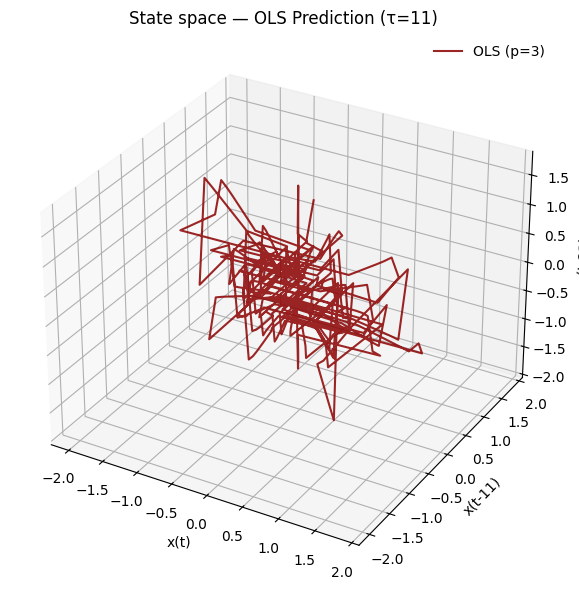

In [30]:
def plot_state_space_compare(X3_true, X3_pinn, X3_ols, p_pinn, p_ols, tau,
                             color_true="black", color_pinn="darkred", color_ols="steelblue"):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    # ax.plot(X3_true[:,0], X3_true[:,1], X3_true[:,2], label="TRUE", color=color_true, alpha=0.85)
    # ax.plot(X3_pinn[:,0], X3_pinn[:,1], X3_pinn[:,2], label=f"PINN (p={p_pinn})", color=color_pinn, alpha=0.85)
    ax.plot(X3_ols[:,0], X3_ols[:,1], X3_ols[:,2], label=f"OLS (p={p_ols})", color=color_pinn, alpha=0.85)
    ax.set_title(f"State space — OLS Prediction (τ={tau})")
    ax.set_xlabel("x(t)")
    ax.set_ylabel(f"x(t-{tau})")
    ax.set_zlabel(f"x(t-{2*tau})")
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()

# --- OLS AR fit on the same validation sample ---
p_ols = 3  # match the true order
Xlag, ylag = AR.lag_matrix(xs, p_ols)
w_ols = AR.fit(Xlag, ylag)
# Full hybrid prediction (refresh_every=10 for fair comparison)
ols_pred_full = AR.hybrid_predict(xs, w_ols, p_ols, start_idx=p_max, n_steps=len(xs)-p_max, refresh_every=10)

ols_mse, ols_mae, ols_corr = AR.metrics(true_full, ols_pred_full)
print(f"OLS AR({p_ols}): MSE={ols_mse:.6f}, MAE={ols_mae:.6f}, corr={ols_corr:.3f}")

tau = 11

# Normalize PINN prediction
pinn_norm = pinn_pred_full - np.mean(pinn_pred_full)
pinn_norm = pinn_norm * (np.std(true_full) / (np.std(pinn_norm) + 1e-12)) + np.mean(true_full)

# Normalize OLS prediction
ols_norm = ols_pred_full - np.mean(ols_pred_full)
ols_norm = ols_norm * (np.std(true_full) / (np.std(ols_norm) + 1e-12)) + np.mean(true_full)

X3_true = embed(true_full, 3, tau)
X3_pinn = embed(pinn_norm, 3, tau)
X3_ols = embed(ols_norm, 3, tau)

plot_state_space_compare(X3_true, X3_pinn, X3_ols, p_pred, p_ols, tau)

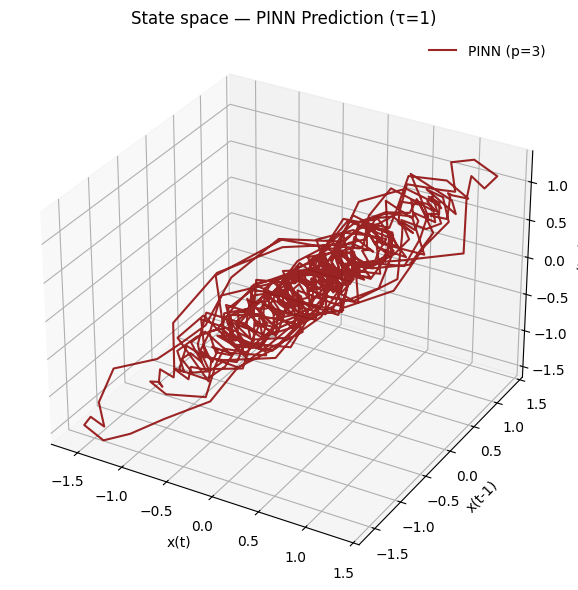

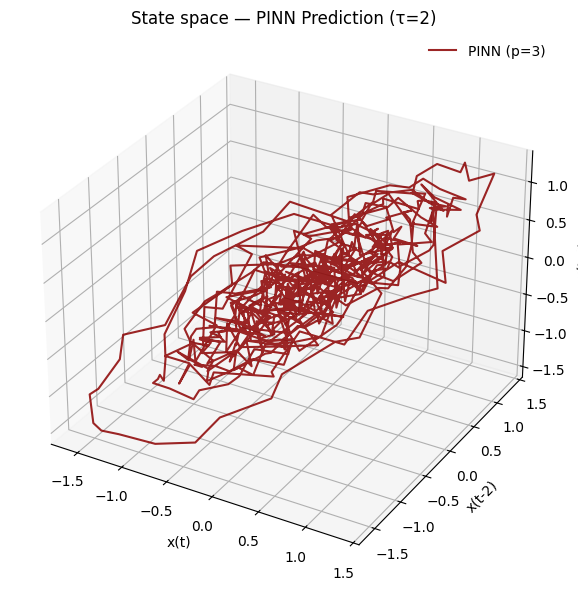

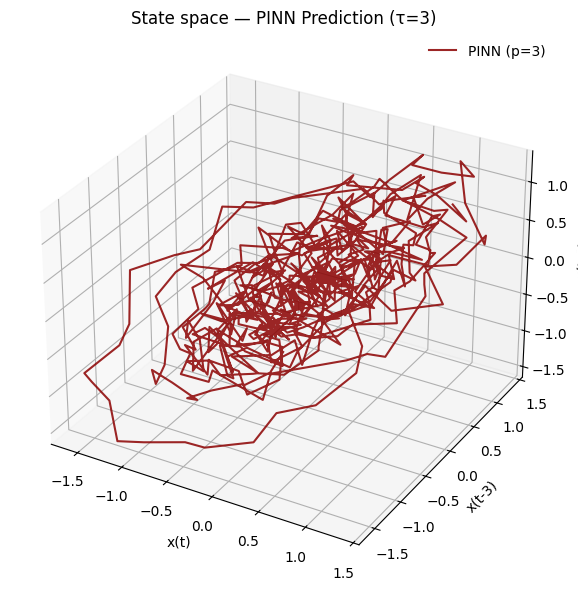

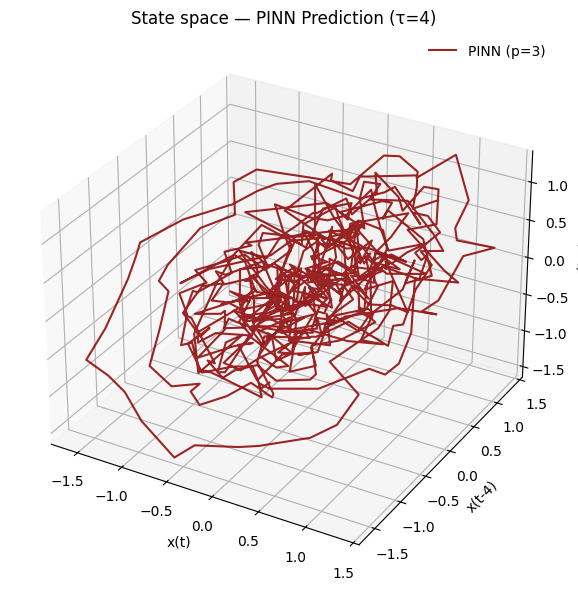

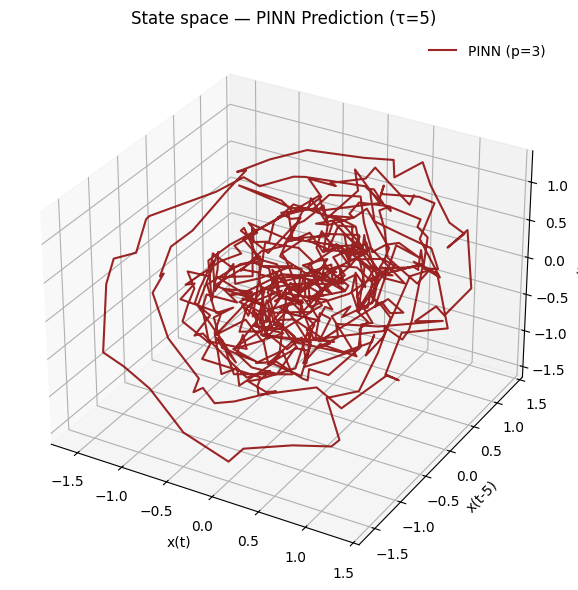

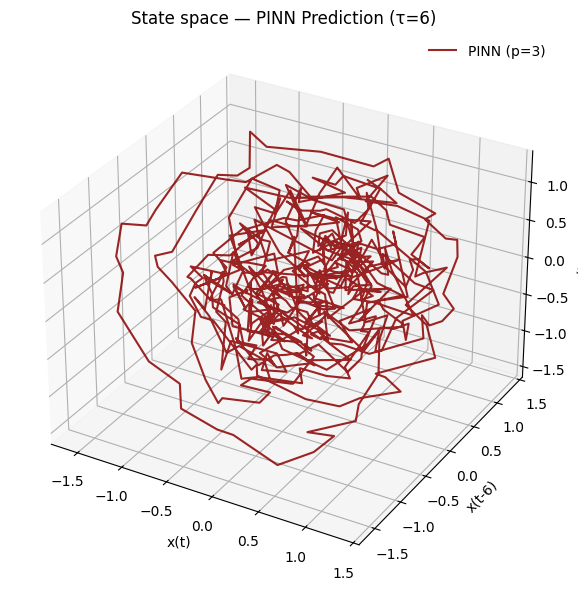

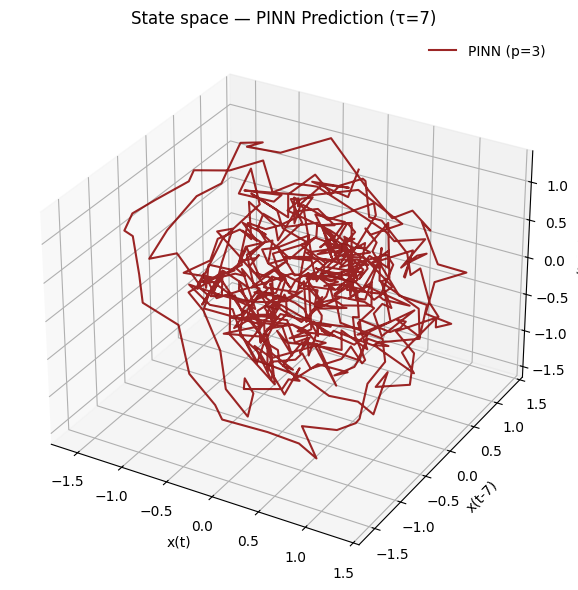

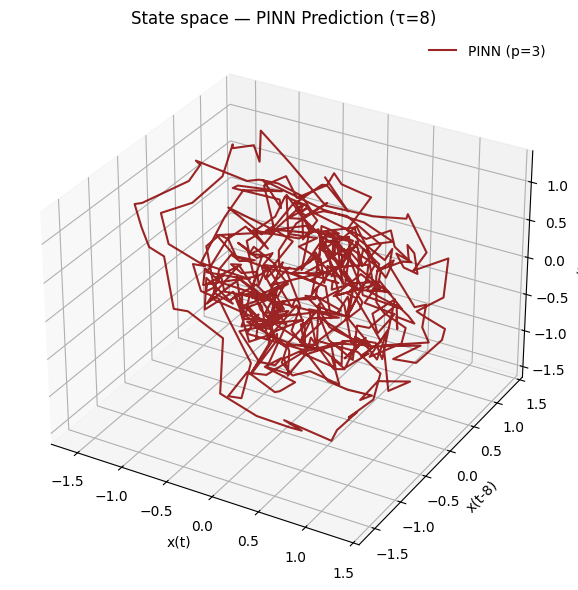

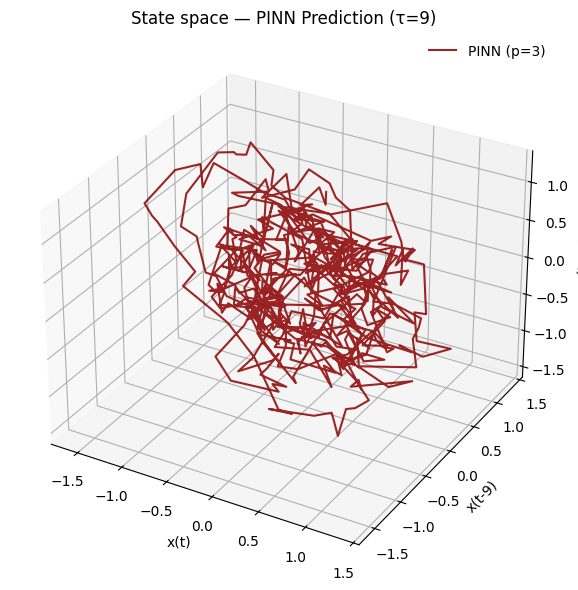

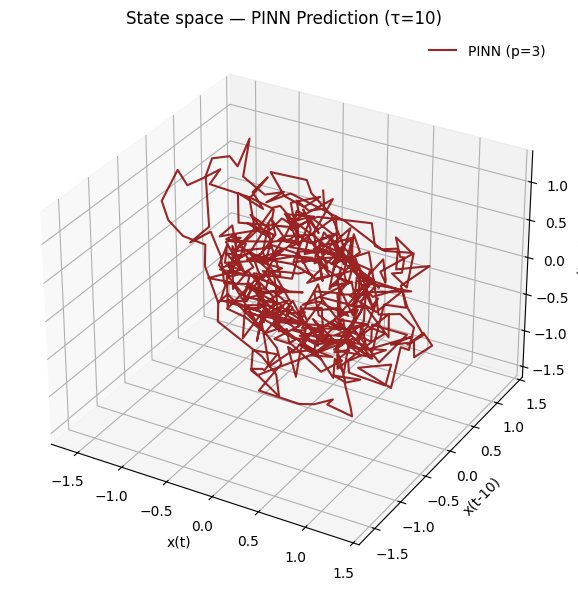

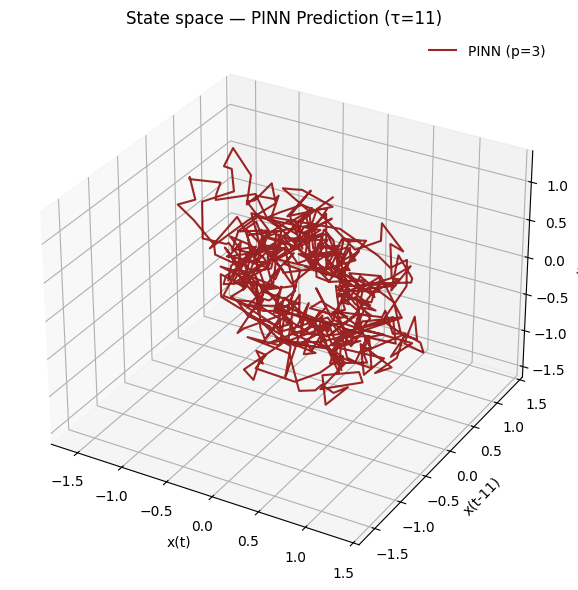

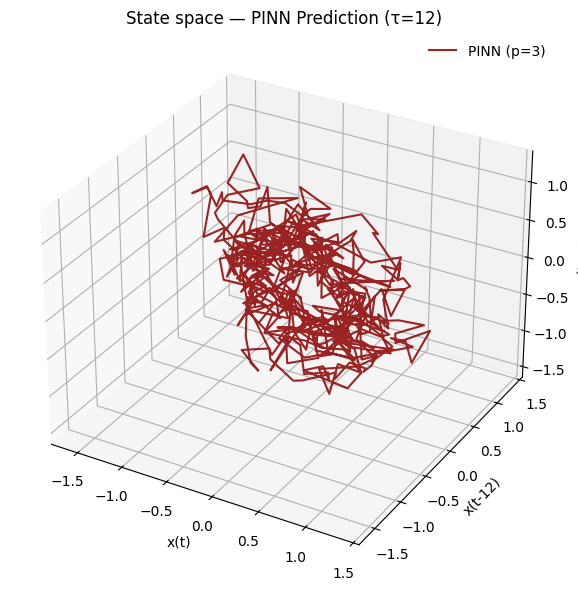

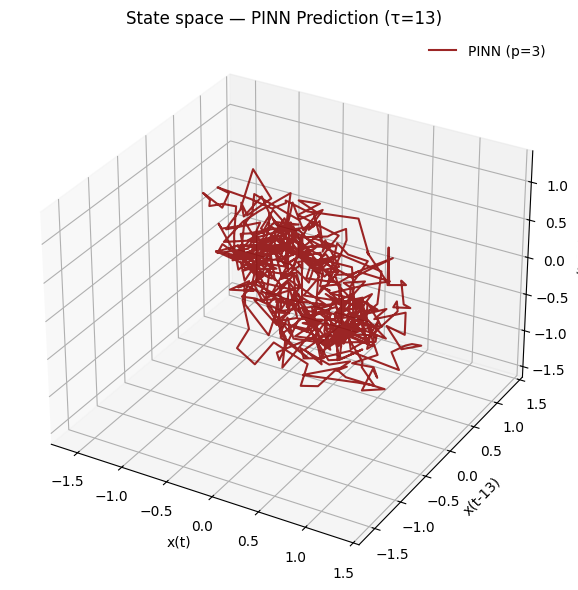

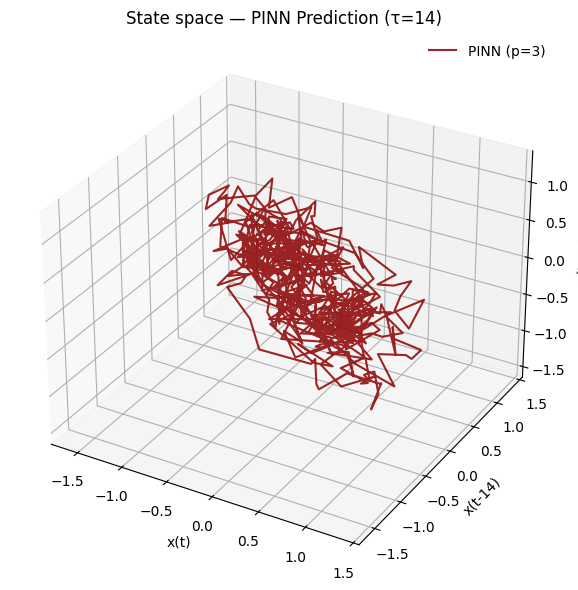

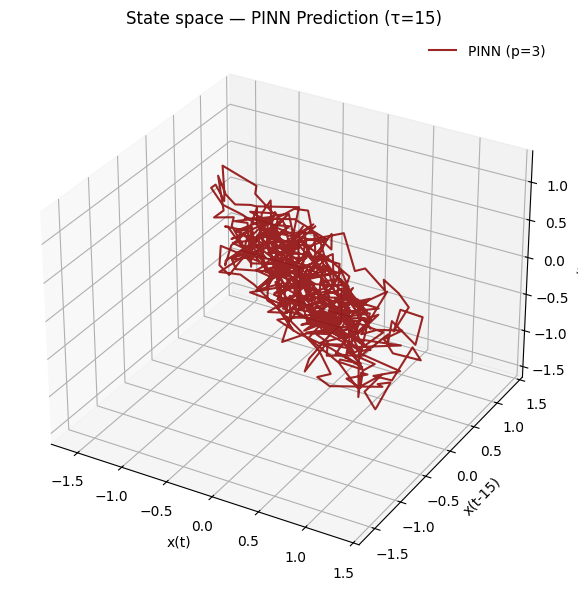

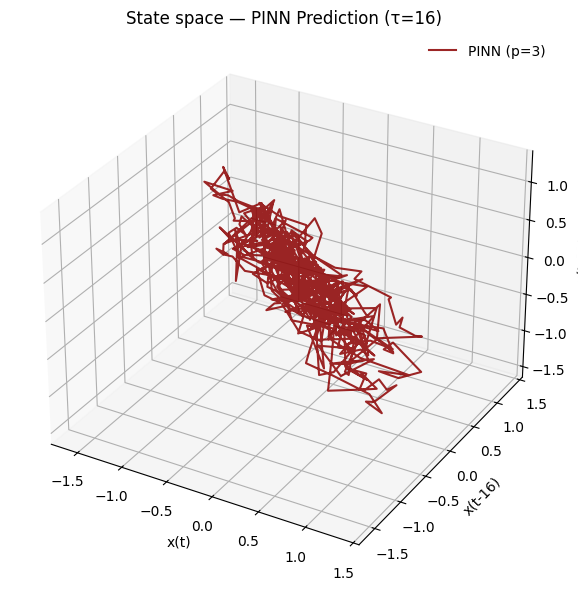

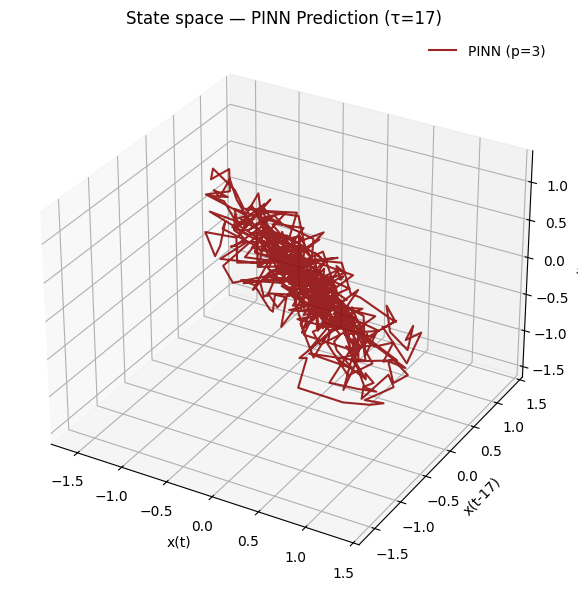

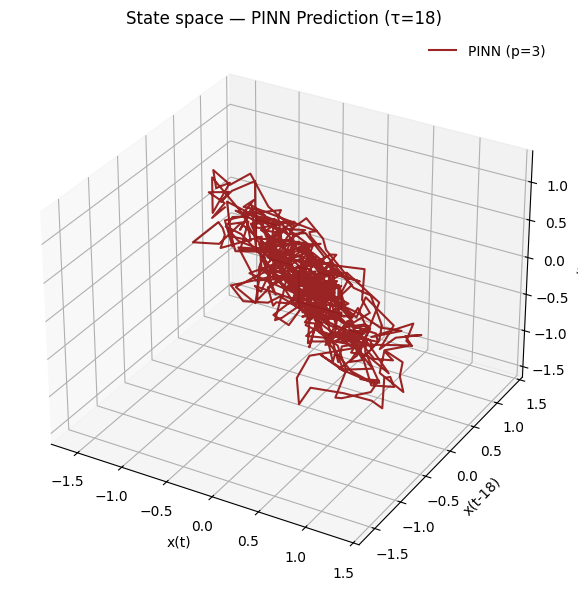

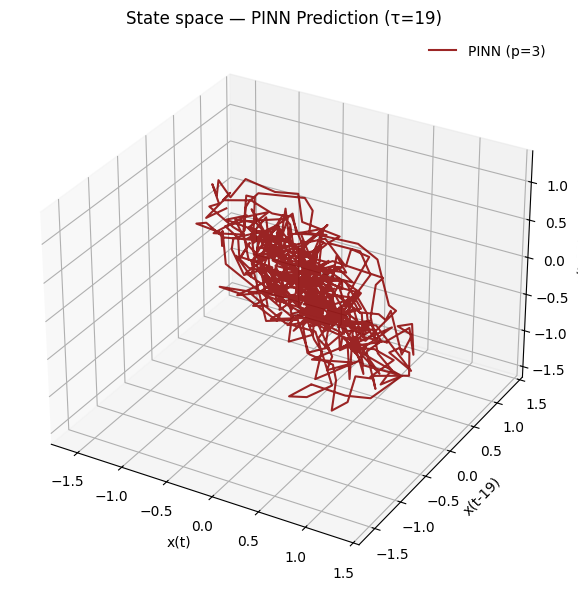

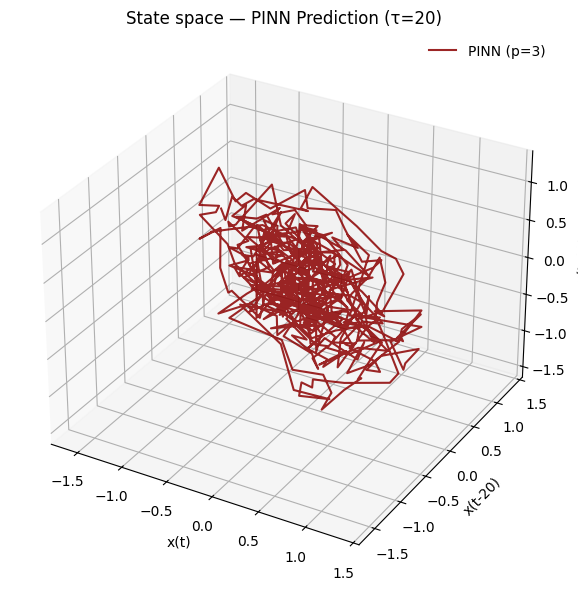

In [31]:
for tau in range(1, 21, 1):
    pinn_norm = pinn_pred_full - np.mean(pinn_pred_full)
    pinn_norm = pinn_norm * (np.std(true_full) / (np.std(pinn_norm) + 1e-12)) + np.mean(true_full)

    X3_true = embed(true_full, 3, tau)
    X3_pinn = embed(pinn_norm, 3, tau)

    plot_state_space(X3_true, X3_pinn, p_pred, tau, method_label="PINN")